------------------------------------------------------------------------Boston House Price Prediction-----------------------------------------------------------------------------







---------------------------------------------------------------------------------------------------------------------------------------------------------

<!-- ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- -->




Dataset → It contains details about houses (like number of rooms, age, crime rate, income level in the area) and the actual house price.

Goal → Build a model that can predict house price when given these features.

Exploration → You first look at the data with charts (scatterplots, heatmaps) to see which features affect price most.

Features & Target → Features (X) are things like rooms, age, crime rate. Target (Y) is the house price.

Train/Test Split → You divide the data into training (to teach the model) and testing (to check accuracy).

Scaling → You resize numbers so all features are on the same scale.

Model Training → You use Linear Regression to learn the relationship between features and price.

Equation → The model gives coefficients and intercept, which form a formula for predicting price.

Prediction → You test the model by predicting prices for unseen data.

Evaluation → You measure accuracy using R² and Adjusted R² to see how well the model explains house prices.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

IMPORTING  ALL THE LIBRARIES

What are Libraries?

* A library is a collection of ready‑made functions and tools.

* Instead of writing everything from scratch, you just import a library and use its features.

1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


import warnings

warnings.filterwarnings('ignore')

This line simply hides warning messages so your output looks clean.

In [6]:
##LETS LOAD THE BOSTON HOUSE DATASET

2. Load the Dataset

In [29]:


# Load dataset from your local file
boston = pd.read_csv(r"C:\Users\Isha\Downloads\M-class\archive\BostonHousing.csv")

# Show first 5 rows
print(boston.head())


      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [30]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

PREPARING THE DATASET

In [32]:
boston=pd.DataFrame( boston)

In [33]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# If you want to rename MEDV to Price
boston['Price'] = boston['medv']


In [35]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,36.2


In [37]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
 14  Price    506 non-null    float64
dtypes: float64(12), int64(3)
memory usage: 59.4 KB


In [48]:
### CHECK THE MISSING VALUE IN THE DATASET
##(.isnull) --USED TO CHECK ALL THE MISSING VALUE IN THE DATASET
boston.isnull().sum()


crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
Price      0
dtype: int64

In [ ]:
# FILLING ALL NULL VALUE USING MEAN 
## (.fillna)--- USED TO FILL ALL NULL VALUE IN THE DATASET

boston['rm'].fillna(boston['rm'].mean(),inplace=True)
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
 14  Price    506 non-null    float64
dtypes: float64(12), int64(3)
memory usage: 59.4 KB


In [45]:
### SUMMARIZING THE STATS OF THE DATA USING 
# (.describe) USED TO DESCRIBE STATS OF THE DATASET
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702085,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.210000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.618750,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000,50.000000


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

3. Exploratory Data Analysis (EDA)

EDA

* EDA means Exploratory Data Analysis.

* It’s the first step in data analysis where you explore your dataset to understand what’s inside before building models.

In [49]:
##LETS START THE EDA 
## CORRELATION

##Correction usually refers to cleaning or fixing your dataset so it’s accurate and usable.
##Examples:

##Fixing wrong column names

##Correcting spelling mistakes in categorical data

##Adjusting outliers (extreme values)

##Handling missing values properly


In [50]:
boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Price
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219261,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.310847,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.392052,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091434,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302051,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321,-0.427321
rm,-0.219261,0.310847,-0.392052,0.091434,-0.302051,1.000000,-0.239632,0.202268,-0.210353,-0.292178,-0.356065,0.127998,-0.614526,0.695375,0.695375
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.239632,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.202268,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.210353,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292178,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536,-0.468536


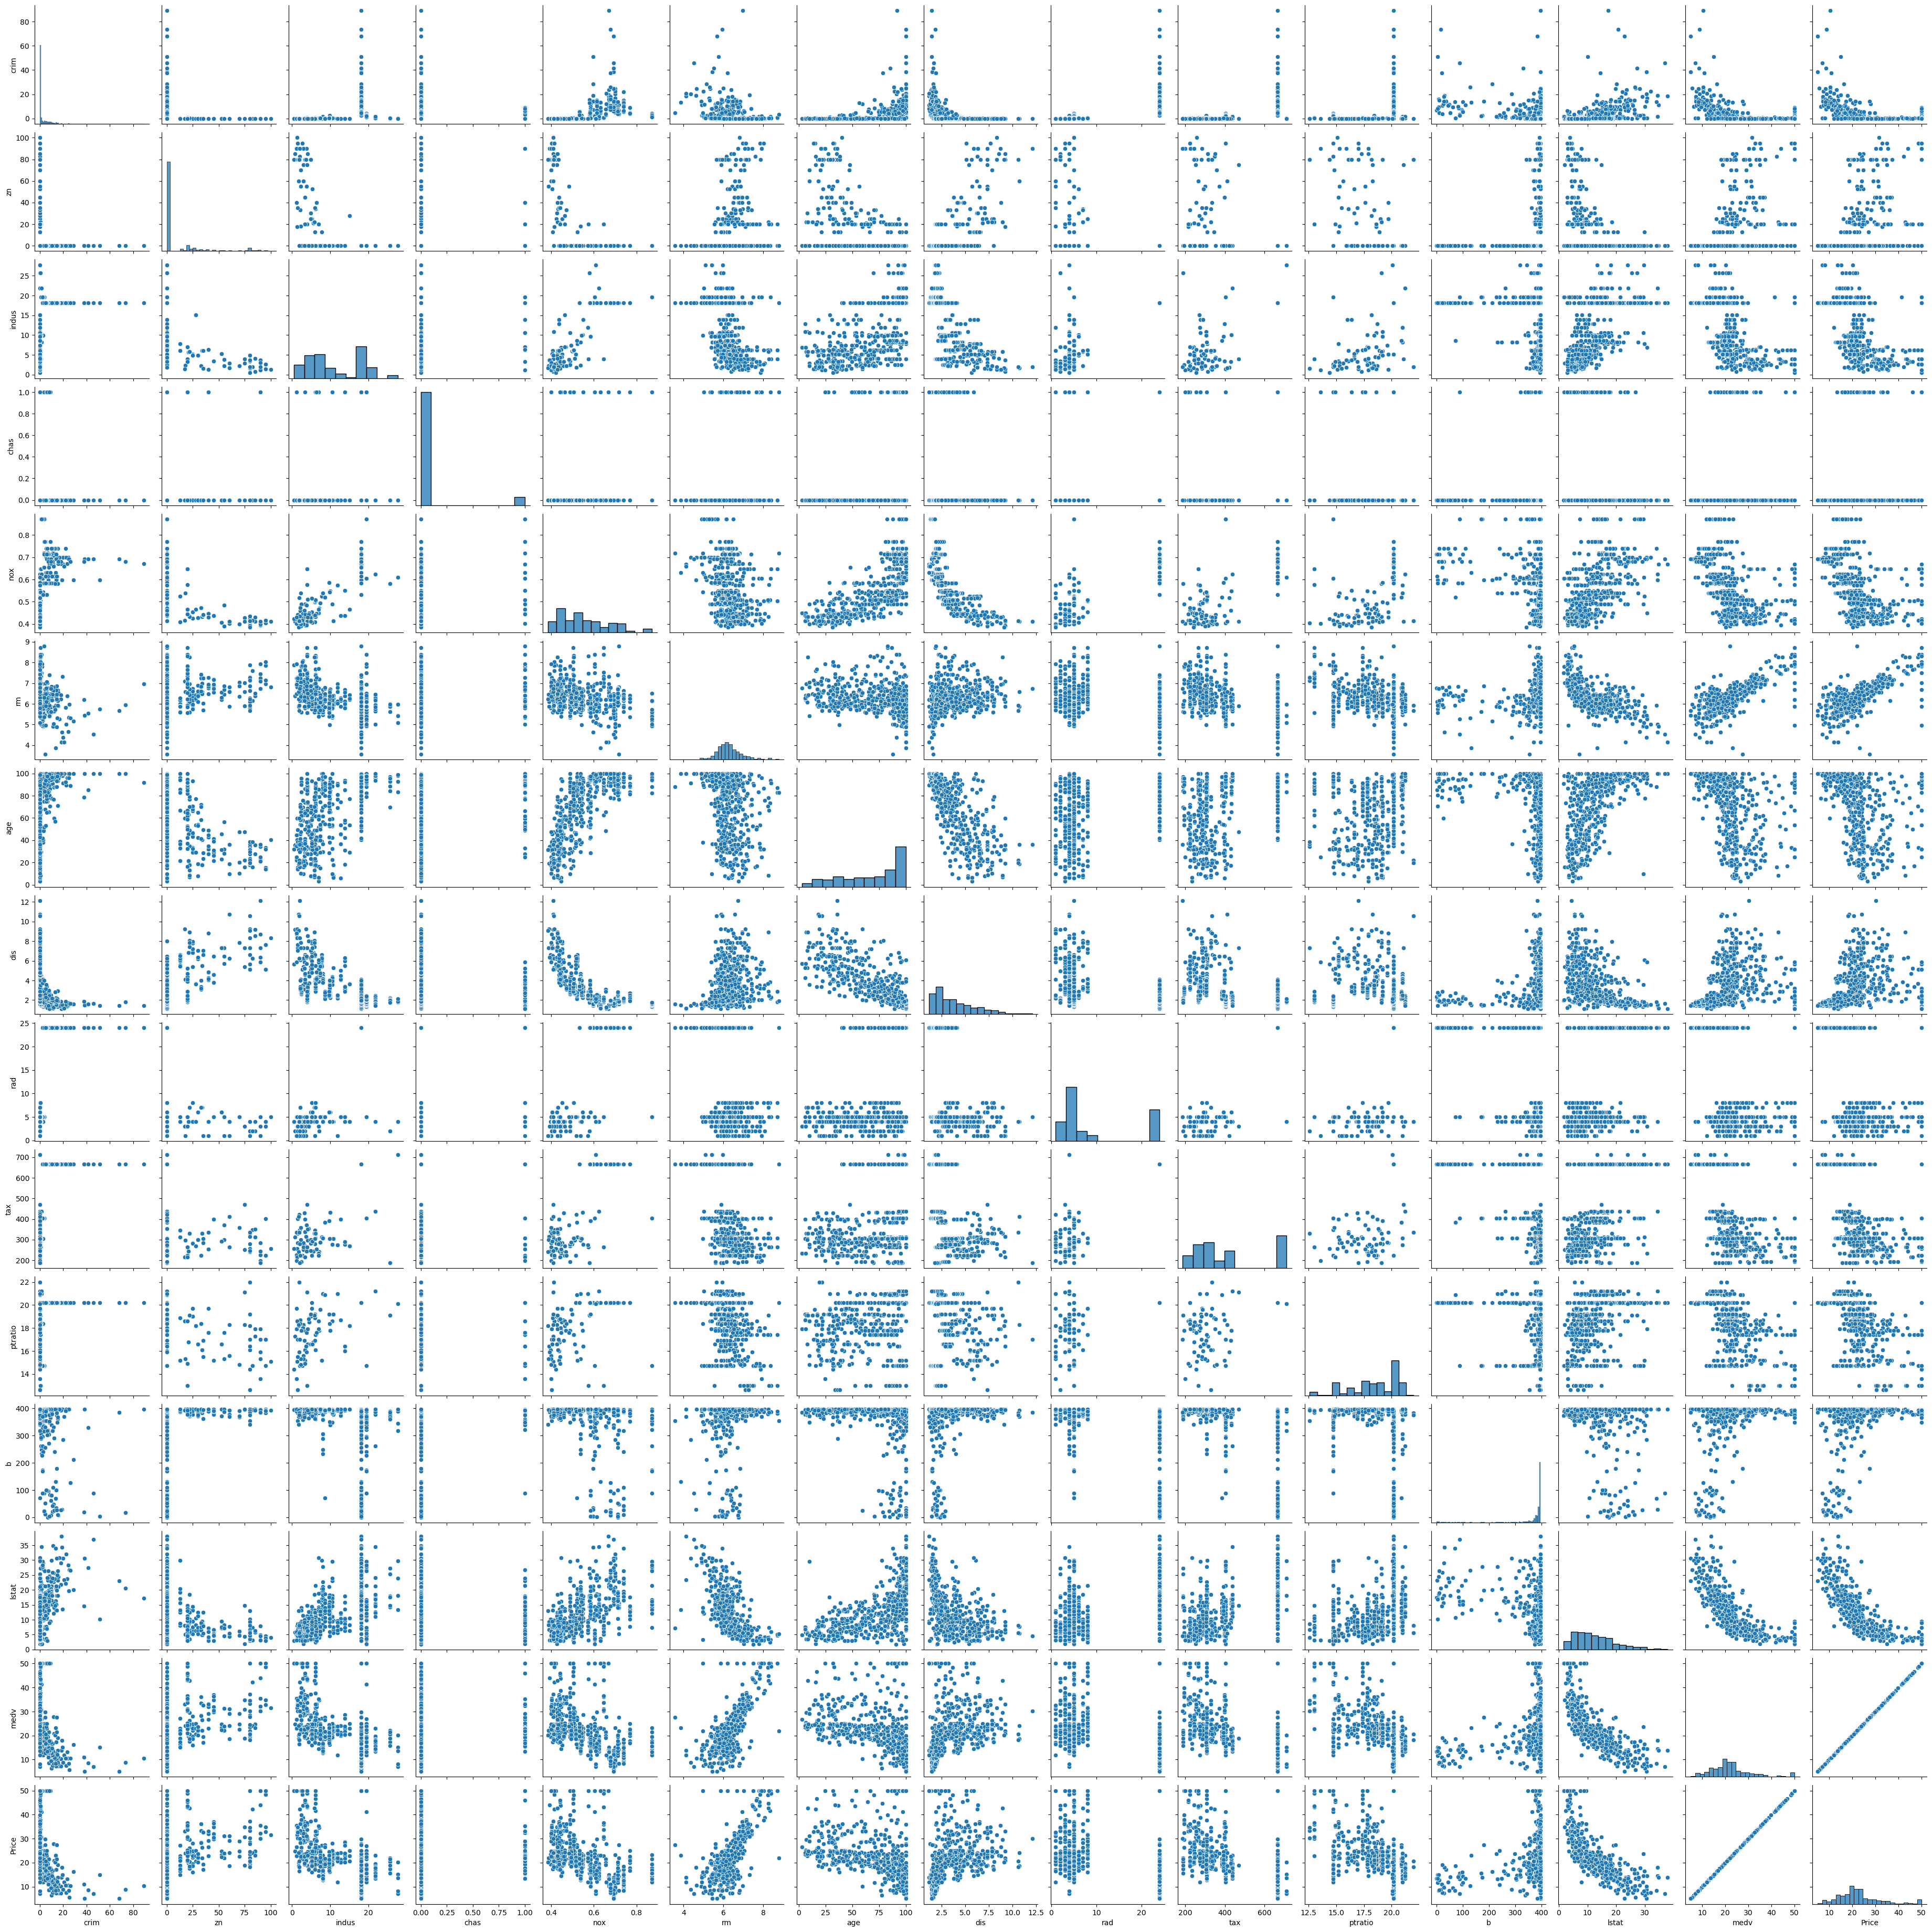

In [53]:
sns.pairplot(boston)
##sns = Seaborn library (used for charts).

##pairplot() = makes a grid of scatter plots for every pair of numeric columns in your dataset.

##It also shows histograms/ KDE plots on the diagonal (for each single column).

##In plain words: it draws all possible comparisons between columns so you can see relationships.

In [55]:
boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,Price
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219261,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.310847,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.392052,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091434,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302051,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321,-0.427321
rm,-0.219261,0.310847,-0.392052,0.091434,-0.302051,1.000000,-0.239632,0.202268,-0.210353,-0.292178,-0.356065,0.127998,-0.614526,0.695375,0.695375
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.239632,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.202268,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.210353,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292178,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536,-0.468536


Text(0, 0.5, 'Price')

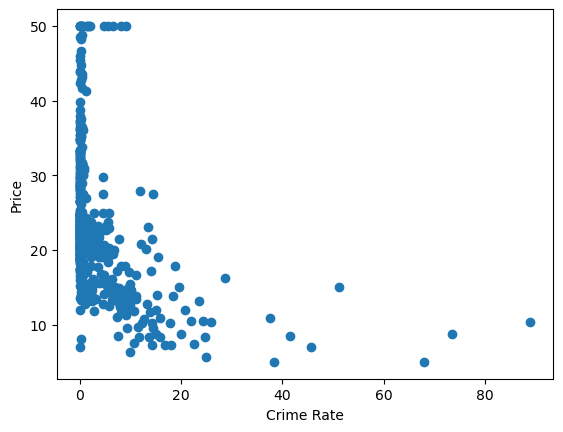

In [57]:
## A scatter plot shows the relationship between two numeric columns using dots

plt.scatter(boston['crim'],boston['Price'])
plt.xlabel('Crime Rate')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

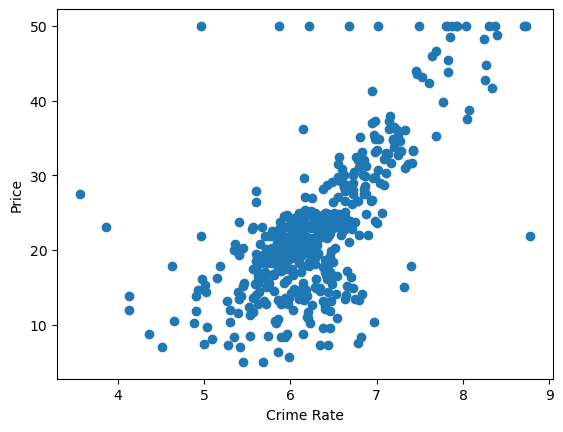

In [59]:
plt.scatter(boston['rm'],boston['Price'])
plt.xlabel('Crime Rate')
plt.ylabel('Price')

<Axes: xlabel='rm', ylabel='Price'>

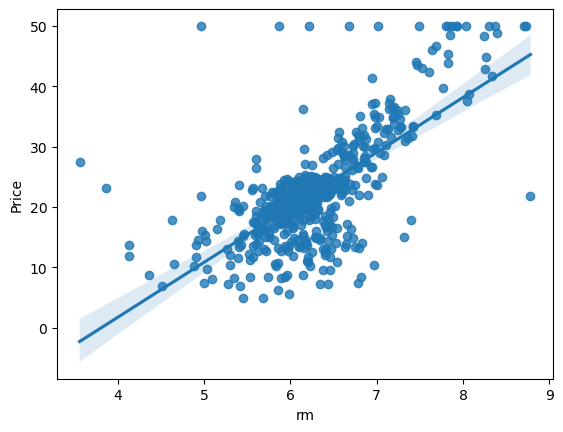

In [63]:
sns.regplot(x='rm',y='Price',data=boston)
##sns.regplot → makes a scatter plot (dots) plus a regression line (trend line)
##So this chart shows dots for each house and a line showing the overall trend (more rooms → higher price)

<Axes: xlabel='lstat', ylabel='Price'>

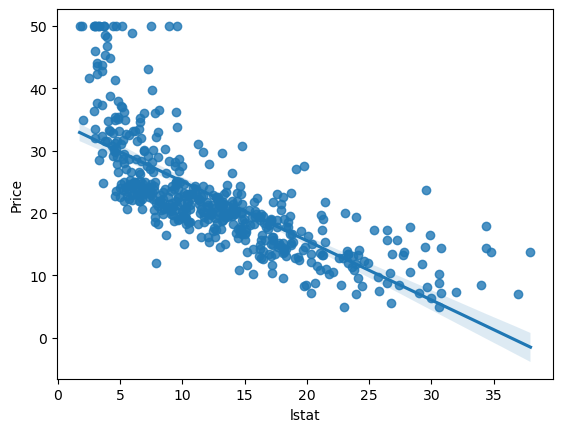

In [65]:
sns.regplot(x='lstat',y='Price',data=boston)
##Negatively related
##This chart tells us that wealthier areas have higher house prices, and poorer areas have lower house prices — a clear negative relationship between LSTAT and Price.

##

In [75]:
# Remove the 'medv' column if it exists
if 'medv' in boston.columns:
	boston.drop(columns='medv', inplace=True)

# Check the remaining columns
print(boston.head())


      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  Price  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

4. Independent & Dependent Features

In [77]:
## INDEPENDENT AND DEPENDENT FEATURES
x=boston.iloc[:,:-1]

##x = boston.iloc[:, :-1]
##: → means all rows.

##:-1 → means all columns except the last one.
##So x contains independent features (inputs) — things like crime rate, rooms, age, etc
y=boston.iloc[:,-1]
##y = boston.iloc[:, -1]
##: → all rows.

##-1 → means the last column only.
## So y contains the dependent feature (output) — usually the house price (medv or Price).

In [80]:
x.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [81]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Price, Length: 506, dtype: float64

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

5. Train-Test Split

In [82]:
##TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

In [85]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
##Training set (70%) = practice questions you study with.

##Test set (30%) = real exam questions you keep aside to check how well you learned.

##random_state=42 = making sure the practice vs exam split is always the same

##This line simply splits your dataset into training and testing parts so you can train your model on one part and check its performance on the other

In [86]:
x_train

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21
116,0.13158,0.0,10.01,0,0.547,6.176,72.5,2.7301,6,432,17.8,393.30,12.04
45,0.17142,0.0,6.91,0,0.448,5.682,33.8,5.1004,3,233,17.9,396.90,10.21
16,1.05393,0.0,8.14,0,0.538,5.935,29.3,4.4986,4,307,21.0,386.85,6.58
468,15.57570,0.0,18.10,0,0.580,5.926,71.0,2.9084,24,666,20.2,368.74,18.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.520,5.836,91.9,2.2110,5,384,20.9,395.67,18.66
270,0.29916,20.0,6.96,0,0.464,5.856,42.1,4.4290,3,223,18.6,388.65,13.00
348,0.01501,80.0,2.01,0,0.435,6.635,29.7,8.3440,4,280,17.0,390.94,5.99
435,11.16040,0.0,18.10,0,0.740,6.629,94.6,2.1247,24,666,20.2,109.85,23.27


In [87]:
x_test

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296,16.6,395.50,9.04
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,9.72418,0.0,18.10,0,0.740,6.406,97.2,2.0651,24,666,20.2,385.96,19.52
23,0.98843,0.0,8.14,0,0.538,5.813,100.0,4.0952,4,307,21.0,394.54,19.88
225,0.52693,0.0,6.20,0,0.504,8.725,83.0,2.8944,8,307,17.4,382.00,4.63
433,5.58107,0.0,18.10,0,0.713,6.436,87.9,2.3158,24,666,20.2,100.19,16.22


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

6. Standard Scaling

Standard Scaling means resizing your data so that:

Mean (average) = 0

Standard deviation = 1

 In plain words: it puts all features on the same scale so no column dominates just because its numbers are bigger.

In [88]:
##STANDARDIZE THE DATASET
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [91]:
x_train=scaler.fit_transform(x_train)
x_train

array([[-0.41425879, -0.50512499, -1.29214218, ...,  0.18727079,
         0.39651419, -1.01531611],
       [-0.40200818, -0.50512499, -0.16208345, ..., -0.21208981,
         0.3870674 , -0.05366252],
       [-0.39721053, -0.50512499, -0.60948856, ..., -0.16771641,
         0.42854113, -0.31132373],
       ...,
       [-0.41604586,  3.03838247, -1.3166773 , ..., -0.56707702,
         0.35987906, -0.90549329],
       [ 0.92611293, -0.50512499,  1.00549958, ...,  0.8528718 ,
        -2.87841346,  1.52750437],
       [-0.39030549, -0.50512499, -0.37135358, ...,  1.16348561,
        -3.32828832, -0.25218837]])

In [92]:
x_test=scaler.transform(x_test)
x_test

array([[-0.406801  , -0.50512499, -1.02225586, ..., -0.74457062,
         0.41241246, -0.47605794],
       [-0.41105674,  1.26662874, -0.68165068, ..., -0.30083661,
         0.42854113, -1.25185755],
       [-0.4051199 , -0.50512499,  2.39678516, ...,  0.8084984 ,
         0.35031705,  0.79535229],
       ...,
       [-0.35439903, -0.50512499, -0.71195877, ..., -0.38958342,
         0.25688594, -1.09697922],
       [ 0.25423453, -0.50512499,  1.00549958, ...,  0.8528718 ,
        -2.98970133,  0.53487511],
       [ 0.77732457, -0.50512499,  1.00549958, ...,  0.8528718 ,
         0.33199949,  0.56585078]])

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

7. Model Training

Model training 
   


Model training is the step where your algorithm learns patterns from the training data (x_train, y_train).

x_train = input features (like rooms, age, crime rate).

y_train = output (house price).

In [93]:
from sklearn.linear_model import LinearRegression

In [96]:
regression=LinearRegression()

In [97]:
regression.fit(x_train,y_train)

LinearRegression()

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

8. Coefficients & Intercept

In [98]:
##PRINT THE COEFFICIENTS AND THE INTERCEPT
print(regression.coef_)

##Coefficients = extra marks added for each subject (Math, Science, English).

[-1.10823836  0.81189823  0.35257783  0.81518768 -1.79607311  2.90447276
 -0.29378061 -2.93049502  2.09664195 -1.44672618 -2.05845103  1.02339256
 -3.88893987]


In [99]:
print(regression.intercept_) # intercept
##Intercept = base marks everyone gets (like 20 marks for just writing your name).



23.01581920903955


In [100]:
## ON WHICH PARAMETERS THE MODEL HAS BEEN TRAINED
regression.get_params()
##regression.get_params() is just a way to see what options your model is using.
##It helps you understand or change how the model works.

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

9. Predictions & Evaluation

PREDICTION WITH TEST DATA

In [103]:
reg_pred=regression.predict(x_test)
reg_pred

array([28.63252461, 36.48602086, 15.4189334 , 25.39319615, 18.85542687,
       23.14196315, 17.38803819, 14.06783335, 23.04060004, 20.58567038,
       24.8304966 , 18.54903944, -6.85534914, 21.79886221, 19.22195173,
       26.18174676, 20.2844755 ,  5.62300497, 40.43768792, 17.57865999,
       27.42731845, 30.15917866, 10.93074566, 23.99706963, 18.07925258,
       15.94318816, 23.12256494, 14.55801939, 22.33614573, 19.31522404,
       22.15661595, 25.17988256, 25.29889979, 18.5274093 , 16.62345866,
       17.52123633, 30.9352234 , 20.18058657, 23.9016633 , 24.85660195,
       13.92840266, 31.80230979, 42.55820862, 17.62362431, 26.99706912,
       17.19500817, 13.7957965 , 26.0889121 , 20.31719055, 30.07798888,
       21.32984607, 34.14817303, 15.58954428, 26.08619306, 39.29980093,
       22.99527802, 18.95885672, 33.04454222, 24.83380987, 12.93150916,
       20.74721067, 30.80662141, 31.61362771, 16.28330058, 21.09350412,
       16.58402988, 20.35925216, 26.14458437, 31.05928094, 11.99

SCATTER PLOT FOR THE PREDICTION

In [104]:
### PLOT A SCATTER PLOT FOR THE PREDICTION

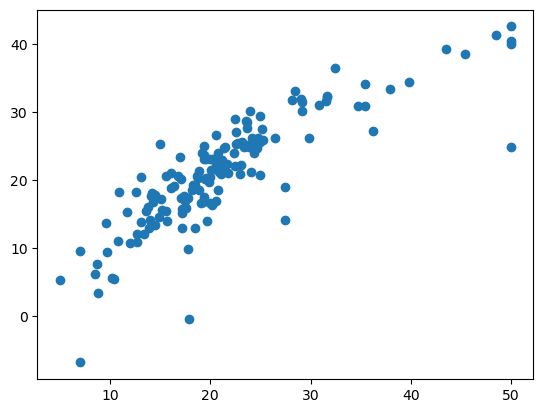

In [105]:
plt.scatter(y_test,reg_pred)

RESIDUALS

In [106]:
#RESIDUALS-- MEANS THE ERROR
residual=y_test-reg_pred
residual

173    -5.032525
274    -4.086021
491    -1.818933
72     -2.593196
452    -2.755427
         ...    
441    -0.301415
23      1.123598
225    10.053915
433    -2.382093
447    -5.687081
Name: Price, Length: 152, dtype: float64

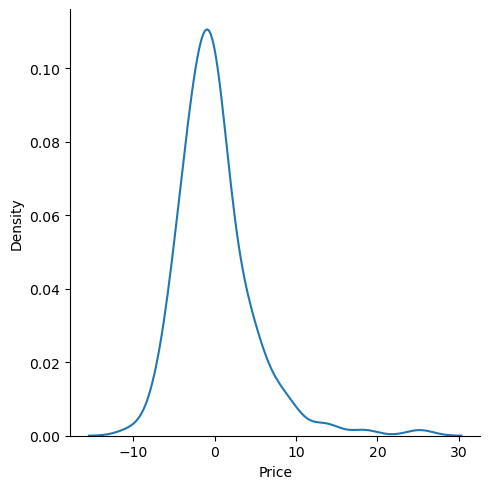

In [107]:
## PLOT THE RESIDUALS
sns.displot(residual,kind='kde')

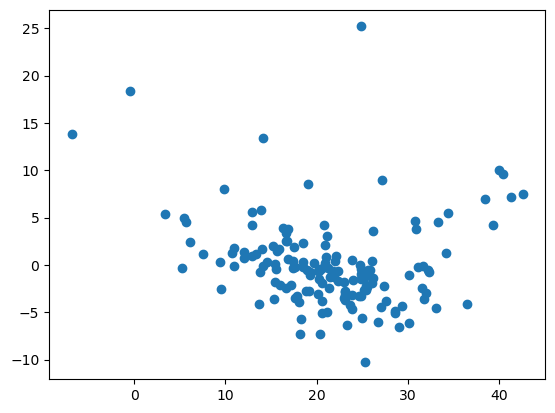

In [110]:
### SCATTER PLOT WITH RESPECT TO PREDICTION AND RESIDUALS
## UNIFORM DISTRIBUTION
plt.scatter(reg_pred,residual)

In [114]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print(mean_absolute_error(y_test,reg_pred))
print(mean_squared_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))

3.1739886727549305
21.598288672542026
4.647395902281408


In [116]:
### R SQUARE AND ADJUSTED R SQUARE
##R² (R‑Square) tells you how much of the variation in your target is explained by your model,
# # while Adjusted R² corrects R² by penalizing unnecessary predictors. R² always increases when you add more variables, but 
# #Adjusted R² only increases if those variables truly improve the model.


In [119]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.7101410361770548


ADJUSTED R2

In [120]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.6828354816140237

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Load data → 2. Explore with charts → 3. Split into inputs/outputs →

Scale numbers → 5. Train model → 6. See formula → 7. Test accuracy
Import libraries → bring in tools like pandas, seaborn, sklearn for data and charts.

Load dataset → open the Boston Housing table with house features and prices.

EDA (exploratory analysis) → use scatterplots, pairplots, heatmaps to see patterns.

Independent vs dependent → split features (X) and target price (Y).

Train-test split → divide data into 70% training (practice) and 30% testing (exam).

Standard scaling → resize numbers so all features are on the same scale.

Model training → fit Linear Regression to learn the relationship between X and Y.

Coefficients & intercept → print the formula the model learned for predicting price.

Predictions → use the model to guess house prices on test data.

Evaluation → check accuracy with MSE, R², and Adjusted R² to see how well the model works.